# Pilot Data Analysis
**Evaluating byT5 parser Performance on 4 repair variant types**

This notebook analyses the PMB-based pilot dataset in which 865 gold sentences wre argumented with four self-repair variants each, parsed by the byT5 parser (Xiao et al., 2025), and evaluated aganist gold SBN using smatch (2013). 

Variant types: 
- **head**: reparandum appers at the start (first ~ 30%) of the sentence
- **mid**: reparandum appears in the middle of the sentence. 
- **tail**: reparandum appears at the end (last ~ 30%). 
- **interrugnum**: self-repair with *I mean* interregnum marker. 

Status codes produced by `evaluate_repair_smatch.py`: 

| Status | Meaning |
|---|---|
| `success` | SBN parsed and smatch computed |
| `ill_formed` | Parser output violates SBN grammar (strict mode) | 
| `parse_error` | Other parsing failure | 
| `gold_error` | Gold SBN itself fails to parse (data quality issue) | 
| `smatch_error` | Parsing succeeded but smatch scoring failed | 

### A More Detailed Elaboration on Status codes for SBN evaluation results
────────────────────────────────────────────────────────────────────────

`success`
    Both the gold SBN and the predicted SBN were successfully parsed
    into a graph (from_string) and serialized into Penman notation
    (to_penman_string). The smatch F1 score was computed normally.
    The f1 column is populated for this row.

`ill_formed`
    The predicted SBN was parsed into a graph (from_string succeeded),
    but the graph failed the structural validity check during Penman
    serialization (to_penman_string raised a Strict mode error). The
    most common cause is a truncated output from the parser: the
    sequence is cut off mid-structure before reaching the 512-token
    limit of the underlying byT5 model, leaving the graph incomplete.
    The f1 column is NaN for this row.

`parse_error`
    The predicted SBN could not be parsed at the token level
    (from_string failed). The parser produced a token that is not
    recognized by the SBN specification, making it impossible to
    construct a graph at all. This represents a more fundamental
    failure than ill_formed.
    The f1 column is NaN for this row.

`gold_error`
    The gold SBN from the PMB reference column (mr) failed to parse.
    In this dataset, all observed gold_error cases were caused by
    accumulated escape characters (e.g. \\\" instead of ") introduced
    during the TSV construction pipeline, not by errors in the original
    PMB annotation.
    The f1 column is NaN for this row.

`smatch_error`
    Both SBNs were successfully converted to Penman notation, but the
    smatch algorithm itself raised an exception during scoring. This
    is expected to be extremely rare in practice.
    The f1 column is NaN for this row.

## Data Argumentation Process
I used `Qwen3-32B-Instruct` to argument the PMB English gold data. The original data structure contains three parts: ID, Natural Language (NL), and SBN Meaning Representation (MR).  
I selected the samples by word length > 8. Then, I inserted the reparandums to each sample by prompt engineering. The logic is keeping the content of the original PMB unchanged, while only inserting new information as reparandums. 

For this pilot study, I define the reparandum as the constituent that semantically competes, while grammatically consistent with the repair. The interregnum is "I mean", for it is more neutral compared to other English interregnums: "actually" importing semantic foci; "no" is a negation marker; "un/um" and "huh" are meaningless phonetic fillers. 

Theoretically, the argumented samples should have the same semantic meaning as the original input, since the added reparandums are semantically retracted, while interregnums work on the metalinguistic level, do not participate in the computation on the discourse/truth-value level.  
Taking id `p73/d2775` as an example:

| Type | Example |
| --- | --- | 
| Original Input: | She chatted with her friends about the baseball game. |
| Head Repair: | **He,** she chatted with her friends about the baseball game. |
| Mid Repair: | She chatted with **her coworkers,** her friends about the baseball game. |
| Tail Repair: | She chatted with her friends about **the basketball game,** the baseball game. |
| Interregnum + Repair: | She chatted with **her coworkers,** *I mean,* her friends about the baseball game. |





In [10]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
import os
import sys

# Define viz style 
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.2)

VARIANT_COLORS= {
    "head": "#4C72B0",
    "mid": "#55A868",
    "tail": "#C44E52",
    "interrug": "#8172B2"
}

VARIANT_ORDER = ["head", "mid", "tail", "interrug"]
VARIANT_LABELS = {
    "head": "Head", 
    "mid": "Mid", 
    "tail": "Tail", 
    "interrug": "Interrug"
}

In [11]:
# Load data 
DATA_PATH = Path("/Users/hongxuzhou/Documents/GitHub/lct_master_project/evaluated_4_type_repair.tsv")

df = pd.read_csv(DATA_PATH, sep="\t", dtype=str)

# Cast F1 columns to numeric, with empty cells to NaN
F1_COLS = [f"repair_{v}_f1" for v in VARIANT_ORDER]
STATUS_COLS = [f"repair_{v}_status" for v in VARIANT_ORDER]

for col in F1_COLS: 
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Sample length by token of the ORIGINAL sample
df["orig_len"] = df["nl"].str.split().str.len()

print(f"Loaded {len(df):,} rows and {len(df.columns)} columns")

df[STATUS_COLS + F1_COLS].head(5)

Loaded 865 rows and 20 columns


,repair_head_status,repair_mid_status,repair_tail_status,repair_interrug_status,repair_head_f1,repair_mid_f1,repair_tail_f1,repair_interrug_f1
0,ill_formed,parse_error,parse_error,parse_error,NaN,NaN,NaN,NaN
1,parse_error,success,success,parse_error,NaN,0.754717,0.754717,NaN
2,parse_error,parse_error,parse_error,success,NaN,NaN,NaN,0.366197
3,success,success,success,parse_error,0.90566,0.771930,0.877193,NaN
4,ill_formed,parse_error,parse_error,parse_error,NaN,NaN,NaN,NaN


## 1. Overall Sample Count 


In [12]:
n_sentences = len(df)
n_total = n_sentences * 4 # one record has 4 variant 

print(f"Original sentences: {n_sentences:,}")
print(f"Repair variants: 4 (head / mid / tail / interrug)")
print(f"Total evaluated: {n_total:,}")

Original sentences: 865
Repair variants: 4 (head / mid / tail / interrug)
Total evaluated: 3,460


## 2. Success Rate per Variant


In [13]:
summary_rows = []
for v in VARIANT_ORDER:
    sc = f"repair_{v}_status"
    vc = df[sc].value_counts()
    n_success = vc.get("success", 0)
    summary_rows.append({
        "Variant": VARIANT_LABELS[v], 
        "N": n_sentences, 
        "Success": n_success,
        "Success %": round(100 * n_success / n_sentences, 2),
        **{s: vc.get(s, 0) for s in ["ill_formed", "parse_error", "gold_error", "smatch_error"]},
        })

summary = pd.DataFrame(summary_rows).set_index("Variant")
display(summary)

,N,Success,Success %,ill_formed,parse_error,gold_error,smatch_error
Variant,,,,,,,
Head,865,591,68.32,50,220,4,0
Mid,865,642,74.22,67,152,4,0
Tail,865,659,76.18,30,172,4,0
Interrug,865,325,37.57,32,504,4,0


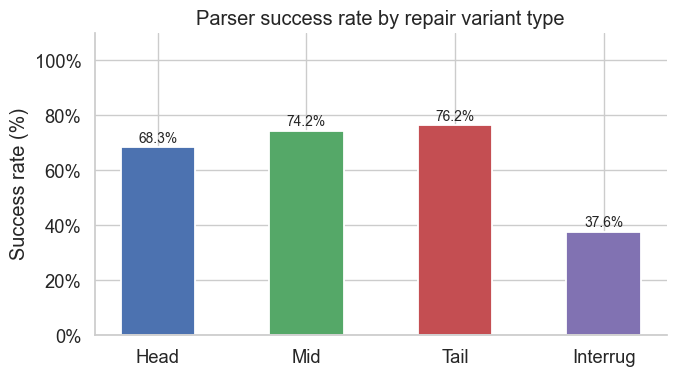

In [14]:
from networkx.algorithms.connectivity import EdgeComponentAuxGraph
from networkx.algorithms.connectivity import edge_augmentation
# Viz -  Bar chart 
fig, ax = plt.subplots(figsize = (7, 4))
bars = ax.bar(
    summary.index, 
    summary["Success %"],
    color = [VARIANT_COLORS[v] for v in VARIANT_ORDER],
    width = 0.5, edgecolor="white", linewidth= 1.3
)

for bar, val in zip(bars, summary["Success %"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
        f"{val:.1f}%", ha="center", va="bottom", fontsize=10)
ax.set_ylim(0, 110)
ax.set_ylabel('Success rate (%)')
ax.set_title('Parser success rate by repair variant type')
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
sns.despine()
plt.tight_layout()
plt.savefig('fig_success_rate.png', dpi=150)
plt.show()

The positional gradient (Head < Mid < Tail) is consistent with left-to-right processing bias. Consider the fact that byT5 is an encoder-docoder model, this is more possibly associated with the autoregressive decoder side: it generates SBN left-to-right, and at each step cross-attends to encoder representations. The SBN output for a sentence typically opens with the main clause's discourse referents and conditions. When the reparandum occupies the early input positions, the decoder's cross-attention during those first generation steps is drawn toward the reparandum tokens which carry no semantic content that should appear in the output, or even if they appear, they should be quarantined. This creates a misalignment between what the decoder needs to generate first and what the most positionally salient encoder states represent. This creates a misalignment between what the decoder needs to generate first and what the most positionally salient encoder states represent.  
Interrgnum is categorically different, instead of just worse. The halved success rate signifies a seperate failure regime. 

### 2.1 Heuristic Truncation Analysis 

We noticed that some of the output SBN sequences are truncated. For example, some end with clearly incomplete word fragments such as "colo", or "En", or even just single letters. This type of SBN sequences usually corresponds to the status `parse_error`. However, truncation, by design, should be categorised to `ill_formed`. The inconsistency indicates a series of silent failure. 
A deeper look at the status suggests that the tag `parse_error` consists of the truncated parsing results. The truncation can be cause by the following factors: 
1. The max length of the parser: The decoder has the max length of 256 tokens (see `config.json` and `generation_config.json` in Xiao's HF, for encoder, max length = 512). Further, the byte-based design of byT5 makes the length longer than sub-word level. 
2. The affect of self-repairs: it has been observed that the reparandum-repair strucuture likely steers the parser to repeat some nodes to achieve the max likelihood of the standard, correct SBN sequence during training. The repeated content, along with the reparandums, extends the length of the SBN sequence. 
3. The inserted interregnum: Specifically to the variety of interregnum + mid-repair, the parser consistently fails to recognise that "I mean" works on the metalinguistic level and so should be ignored during parsing. Thus, it tends to represent it as nodes and force edges to them.

Regarding this, I used a heuristic method to identify the obvious truncation, based on the hypothesis that the obvious truncation is a subset of truncation, and the frequency of the obvious truncation can, to some extent, signify the seriousness of truncation issues among all four varieties. 

In [15]:
notebook_dir = Path.cwd()
target_dir = (
    notebook_dir.parent / "data" / "pmb-5.1.0" / "src" / "sbn"
).resolve()

if str(target_dir) not in sys.path:
    sys.path.append(str(target_dir))

from truncation_detect import is_obvious_truncation

for v in VARIANT_LABELS:
    df[f"repair_{v}_truncated"] = df[f"repair_{v}_sbn"].apply(
        lambda x: is_obvious_truncation(str(x))
    )

# Report 
total = len(df)
rows = []

for v in VARIANT_LABELS:
    status_col = f"repair_{v}_status"
    trunc_col  = f"repair_{v}_truncated"

    n_trunc    = df[trunc_col].sum()
    pct_trunc  = 100 * n_trunc / total

    pe_mask    = df[status_col] == "parse_error"
    n_pe       = pe_mask.sum()
    n_pe_trunc = (pe_mask & df[trunc_col]).sum()
    pct_pe_trunc = 100 * n_pe_trunc / n_pe if n_pe > 0 else float("nan")

    rows.append({
        "Variant":                v.capitalize(),
        "N":                      total,
        "Obvious truncations":    n_trunc,
        "Trunc %":                round(pct_trunc, 1),
        "parse_error (total)":    n_pe,
        "parse_error → truncated": n_pe_trunc,
        "% of parse_error":       round(pct_pe_trunc, 1),
    })

summary = pd.DataFrame(rows)
print(summary.to_string(index=False))

 Variant   N  Obvious truncations  Trunc %  parse_error (total)  parse_error → truncated  % of parse_error
    Head 865                  247     28.6                  220                      176              80.0
     Mid 865                  188     21.7                  152                      120              78.9
    Tail 865                  190     22.0                  172                      127              73.8
Interrug 865                  428     49.5                  504                      369              73.2


In [19]:
# NEW COLUMN: Byte length
for v in VARIANT_LABELS:
    df[f"repair_{v}_sbn_bytes"] = df[f"repair_{v}_sbn"].apply(
        lambda x: len(str(x).encode("utf-8")) if pd.notna(x) else 0
    )

# Distribution of truncated vs. non-truncated
print(f"\n{'Variant':<10} {'Trunc mean':>12} {'Trunc median':>14} "
      f"{'Non-trunc mean':>16} {'Non-trunc median':>18} {'Near-256 (≥240)':>17}")
print("─" * 92)

for v in VARIANT_LABELS:
    trunc_col  = f"repair_{v}_truncated"
    bytes_col  = f"repair_{v}_sbn_bytes"

    trunc_len     = df.loc[df[trunc_col],  bytes_col]
    nontrunc_len  = df.loc[~df[trunc_col], bytes_col]
    near_256      = (trunc_len >= 240).sum()
    pct_near      = 100 * near_256 / len(trunc_len) if len(trunc_len) > 0 else float("nan")

    print(f"{v.capitalize():<10} "
          f"{trunc_len.mean():>12.1f} "
          f"{trunc_len.median():>14.1f} "
          f"{nontrunc_len.mean():>16.1f} "
          f"{nontrunc_len.median():>18.1f} "
          f"{near_256:>8} ({pct_near:.0f}%)")


Variant      Trunc mean   Trunc median   Non-trunc mean   Non-trunc median   Near-256 (≥240)
────────────────────────────────────────────────────────────────────────────────────────────
Head              244.4          256.0            206.9              210.0      200 (81%)
Mid               239.5          255.0            200.9              203.0      140 (74%)
Tail              237.9          255.0            200.6              204.0      144 (76%)
Interrug          253.8          255.0            234.5              252.0      413 (96%)


In [20]:
import numpy as np

print("Length Statistics of Obvious Truncation：\n")
print(f"{'Variant':<10} {'min':>6} {'p25':>6} {'p50':>6} {'p75':>6} "
      f"{'p90':>6} {'p95':>6} {'max':>6} {'≥240,≤260':>12}")
print("─" * 80)

for v in VARIANT_LABELS:
    trunc_col = f"repair_{v}_truncated"
    bytes_col = f"repair_{v}_sbn_bytes"

    lengths = df.loc[df[trunc_col], bytes_col]
    if len(lengths) == 0:
        continue

    pcts = np.percentile(lengths, [25, 50, 75, 90, 95])
    #near_512 = (lengths >= 500).sum()
    near_256 = ((lengths >= 240) & (lengths <= 260)).sum()

    print(f"{v.capitalize():<10} "
          f"{lengths.min():>6.0f} "
          f"{pcts[0]:>6.0f} "
          f"{pcts[1]:>6.0f} "
          f"{pcts[2]:>6.0f} "
          f"{pcts[3]:>6.0f} "
          f"{pcts[4]:>6.0f} "
          f"{lengths.max():>6.0f} "
          #f"{near_512:>8} "
          f"{near_256:>12}")


print("\nThe MAX byte length of the truncated sequences：")
for v in VARIANT_LABELS:
    trunc_col = f"repair_{v}_truncated"
    bytes_col = f"repair_{v}_sbn_bytes"
    lengths = df.loc[df[trunc_col], bytes_col]
    top10 = sorted(lengths.tolist(), reverse=True)[:10]
    print(f"  {v.capitalize():<10} top-10 lengths: {top10}")

Length Statistics of Obvious Truncation：

Variant       min    p25    p50    p75    p90    p95    max    ≥240,≤260
────────────────────────────────────────────────────────────────────────────────
Head          146    254    256    257    257    258    259          200
Mid           134    238    255    256    257    258    259          140
Tail          124    248    255    256    257    258    260          144
Interrug      145    255    255    256    257    257    259          413

The MAX byte length of the truncated sequences：
  Head       top-10 lengths: [259, 259, 259, 259, 259, 259, 259, 258, 258, 258]
  Mid        top-10 lengths: [259, 259, 259, 259, 259, 258, 258, 258, 258, 258]
  Tail       top-10 lengths: [260, 259, 259, 259, 258, 258, 258, 258, 258, 258]
  Interrug   top-10 lengths: [259, 259, 259, 259, 258, 258, 258, 258, 258, 258]


## 3  Failure Cause Breakdown

> **Note on `gold_error`**: these failures reflect the gold SBN being unparseable, *not* a parser deficiency.
> They are shown separately and excluded from the parser-failure proportions.


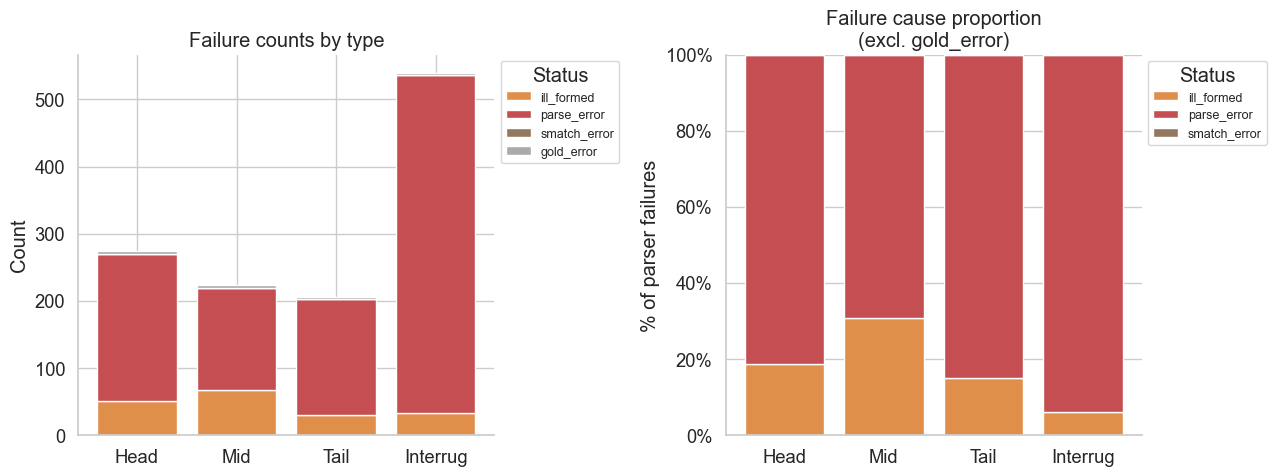

In [ ]:
FAIL_STATUSES = ['ill_formed', 'parse_error', 'smatch_error', 'gold_error']
FAIL_COLORS   = {
    'ill_formed':   '#E08F4B',
    'parse_error':  '#C44E52',
    'smatch_error': '#937860',
    'gold_error':   '#AAAAAA',
}

# Stacked bar: absolute counts
fail_data = summary[FAIL_STATUSES].copy()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: absolute
bottom = np.zeros(len(VARIANT_ORDER))
for fs in FAIL_STATUSES:
    vals = fail_data[fs].values.astype(float)
    axes[0].bar(fail_data.index, vals, bottom=bottom,
                label=fs, color=FAIL_COLORS[fs], edgecolor='white')
    bottom += vals
axes[0].set_title('Failure counts by type')
axes[0].set_ylabel('Count')
axes[0].legend(title='Status', bbox_to_anchor=(1, 1), loc='upper left', fontsize=9)
sns.despine(ax=axes[0])

# Right: proportions (within failures only, gold_error separated)
fail_only = fail_data[['ill_formed', 'parse_error', 'smatch_error']]
fail_pct  = fail_only.div(fail_only.sum(axis=1), axis=0) * 100
bottom2   = np.zeros(len(VARIANT_ORDER))
for fs in ['ill_formed', 'parse_error', 'smatch_error']:
    vals = fail_pct[fs].values.astype(float)
    axes[1].bar(fail_pct.index, vals, bottom=bottom2,
                label=fs, color=FAIL_COLORS[fs], edgecolor='white')
    bottom2 += vals
axes[1].set_title('Failure cause proportion\n(excl. gold_error)')
axes[1].set_ylabel('% of parser failures')
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter())
axes[1].legend(title='Status', bbox_to_anchor=(1, 1), loc='upper left', fontsize=9)
sns.despine(ax=axes[1])

plt.tight_layout()
plt.savefig('fig_failure_breakdown.png', dpi=150)
plt.show()

## 4  F1 Score Analysis

We report three reporting scopes:

| Scope | Description |
|---|---|
| **A — Success only** | F1 computed only over sentences where parsing succeeded |
| **B — Penalised (excl. gold_error)** | Failures (excl. `gold_error`) treated as F1 = 0 |
| **C — Penalised (all)** | All non-success rows treated as F1 = 0 |

In [ ]:
f1_rows = []
for v in VARIANT_ORDER:
    sc  = f'repair_{v}_status'
    f1c = f'repair_{v}_f1'

    f1_success = df.loc[df[sc] == 'success', f1c]

    # Scope B: failures except gold_error → 0
    f1_b = df[f1c].copy()
    mask_b = (df[sc] != 'success') & (df[sc] != 'gold_error')
    f1_b.loc[mask_b] = 0.0
    # gold_error rows stay NaN → excluded from mean

    # Scope C: all non-success → 0
    f1_c = df[f1c].fillna(0.0)
    f1_c.loc[df[sc] != 'success'] = 0.0

    f1_rows.append({
        'Variant':        VARIANT_LABELS[v],
        'A mean':         round(f1_success.mean(), 4),
        'A median':       round(f1_success.median(), 4),
        'A n':            len(f1_success),
        'B mean (pen.)':  round(f1_b.mean(), 4),
        'C mean (all 0)': round(f1_c.mean(), 4),
    })

f1_summary = pd.DataFrame(f1_rows).set_index('Variant')
display(f1_summary)

,A mean,A median,A n,B mean (pen.),C mean (all 0)
Variant,,,,,
Head,0.7830,0.8000,591,0.5375,0.5350
Mid,0.8063,0.8142,642,0.6012,0.5984
Tail,0.8346,0.8571,659,0.6388,0.6359
Interrug,0.6088,0.5763,325,0.2298,0.2287


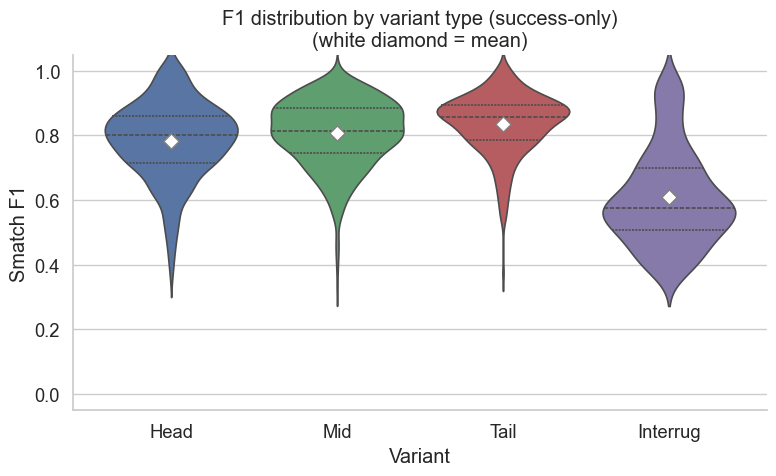

In [ ]:
# Violin + strip plot: F1 distribution per variant (success-only)
plot_rows = []
for v in VARIANT_ORDER:
    sc  = f'repair_{v}_status'
    f1c = f'repair_{v}_f1'
    vals = df.loc[df[sc] == 'success', f1c].dropna()
    for val in vals:
        plot_rows.append({'Variant': VARIANT_LABELS[v], 'F1': val})

plot_df = pd.DataFrame(plot_rows)

# palette keyed by display label (capitalised), matching VARIANT_LABELS values
label_colors = {VARIANT_LABELS[v]: VARIANT_COLORS[v] for v in VARIANT_ORDER}

fig, ax = plt.subplots(figsize=(8, 5))
sns.violinplot(
    data=plot_df, x='Variant', y='F1', hue='Variant',
    order=[VARIANT_LABELS[v] for v in VARIANT_ORDER],
    palette=label_colors,
    inner='quartile', linewidth=1.2, legend=False, ax=ax
)
# Overlay mean as white diamond
means = plot_df.groupby('Variant')['F1'].mean()
for i, v in enumerate(VARIANT_ORDER):
    label = VARIANT_LABELS[v]
    if label in means.index:
        ax.scatter(i, means[label], color='white', zorder=5, s=60,
                   marker='D', edgecolor='grey')

ax.set_ylim(-0.05, 1.05)
ax.set_ylabel('Smatch F1')
ax.set_title('F1 distribution by variant type (success-only)\n(white diamond = mean)')
sns.despine()
plt.tight_layout()
plt.savefig('fig_f1_violin.png', dpi=150)
plt.show()

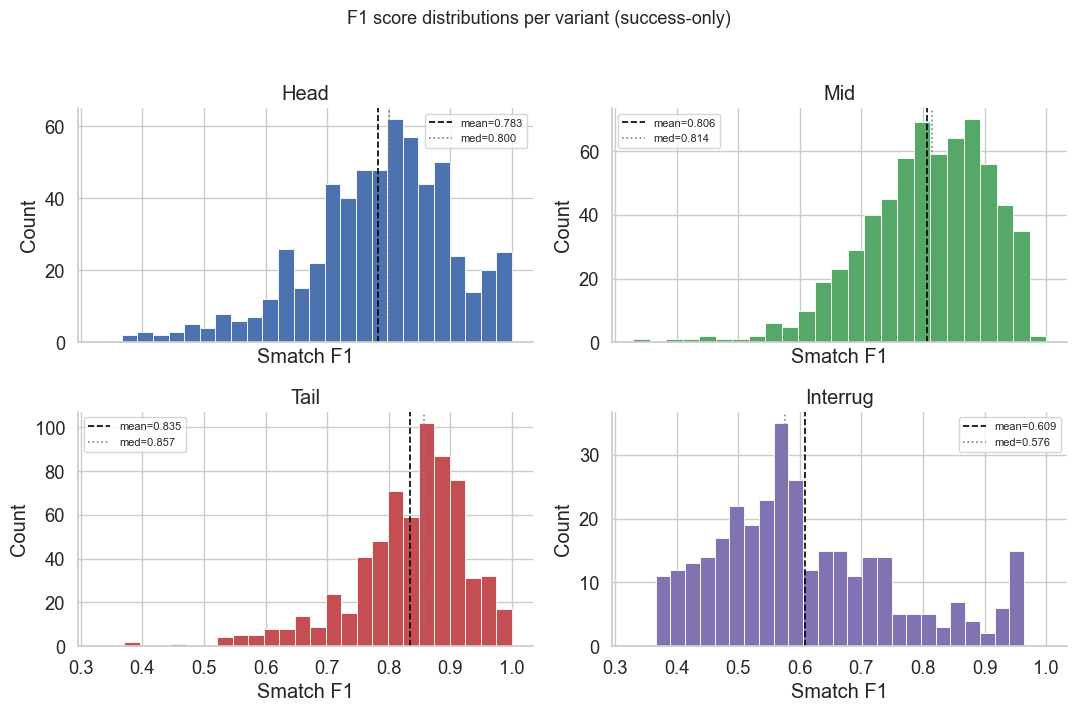

In [ ]:
# Histogram grid: F1 distributions
fig, axes = plt.subplots(2, 2, figsize=(11, 7), sharex=True, sharey=False)
axes = axes.flatten()

for ax, v in zip(axes, VARIANT_ORDER):
    sc  = f'repair_{v}_status'
    f1c = f'repair_{v}_f1'
    vals = df.loc[df[sc] == 'success', f1c].dropna()
    ax.hist(vals, bins=25, color=VARIANT_COLORS[v], edgecolor='white', linewidth=0.6)
    ax.axvline(vals.mean(),   color='black', linestyle='--', linewidth=1.2, label=f'mean={vals.mean():.3f}')
    ax.axvline(vals.median(), color='grey',  linestyle=':',  linewidth=1.2, label=f'med={vals.median():.3f}')
    ax.set_title(VARIANT_LABELS[v])
    ax.set_xlabel('Smatch F1')
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)
    sns.despine(ax=ax)

fig.suptitle('F1 score distributions per variant (success-only)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('fig_f1_histograms.png', dpi=150)
plt.show()

---
## 5  Sentence-Level Coverage Analysis

Because each of the 865 sentences contributes 4 variant records, we can ask
how many sentences have *all*, *some*, or *no* variants parsed successfully.

                    Sentences
Variants succeeded           
0                          70
1                          97
2                         174
3                         324
4                         200

Sentences with ALL 4 succeeded : 200
Sentences with NONE succeeded  : 70


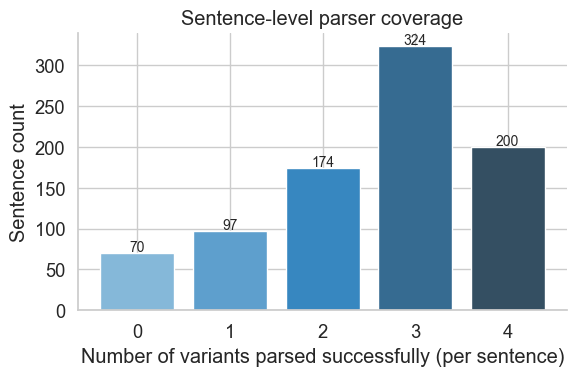

In [ ]:
# Count successes per sentence
df['n_success'] = sum(
    (df[f'repair_{v}_status'] == 'success').astype(int)
    for v in VARIANT_ORDER
)

coverage = df['n_success'].value_counts().sort_index()
coverage.index.name = 'Variants succeeded'
coverage.name = 'Sentences'
print(coverage.to_frame())
print(f"\nSentences with ALL 4 succeeded : {(df['n_success'] == 4).sum()}")
print(f"Sentences with NONE succeeded  : {(df['n_success'] == 0).sum()}")

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(coverage.index.astype(str), coverage.values,
       color=sns.color_palette('Blues_d', len(coverage)), edgecolor='white')
for x, y in zip(coverage.index.astype(str), coverage.values):
    ax.text(x, y + 2, str(y), ha='center', fontsize=10)
ax.set_xlabel('Number of variants parsed successfully (per sentence)')
ax.set_ylabel('Sentence count')
ax.set_title('Sentence-level parser coverage')
sns.despine()
plt.tight_layout()
plt.savefig('fig_coverage.png', dpi=150)
plt.show()

## 6  Sentence Length vs. Failure Rate

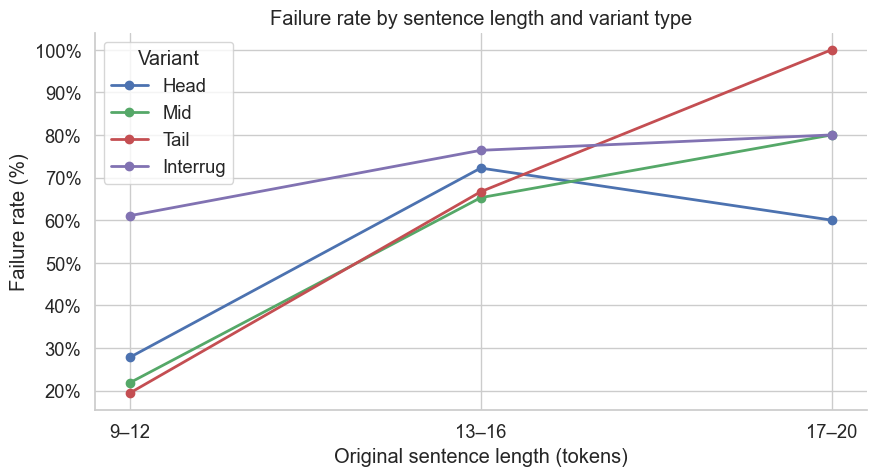

In [ ]:
# Bin sentences by original length; compute failure rate per variant in each bin
bins = [0, 8, 12, 16, 20, 100]
labels = ['≤8', '9–12', '13–16', '17–20', '>20']
df['len_bin'] = pd.cut(df['orig_len'], bins=bins, labels=labels)

fig, ax = plt.subplots(figsize=(9, 5))
for v in VARIANT_ORDER:
    sc = f'repair_{v}_status'
    fail_rate = df.groupby('len_bin', observed=True).apply(
        lambda g: (g[sc] != 'success').mean() * 100
    )
    ax.plot(fail_rate.index, fail_rate.values,
            marker='o', label=VARIANT_LABELS[v], color=VARIANT_COLORS[v], linewidth=2)

ax.set_xlabel('Original sentence length (tokens)')
ax.set_ylabel('Failure rate (%)')
ax.set_title('Failure rate by sentence length and variant type')
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.legend(title='Variant')
sns.despine()
plt.tight_layout()
plt.savefig('fig_length_vs_failure.png', dpi=150)
plt.show()

## 7  Summary Table 

In [ ]:
pub_rows = []
for v in VARIANT_ORDER:
    sc  = f'repair_{v}_status'
    f1c = f'repair_{v}_f1'
    vc  = df[sc].value_counts()

    n_success     = vc.get('success', 0)
    n_ill         = vc.get('ill_formed', 0)
    n_parse       = vc.get('parse_error', 0)
    n_gold        = vc.get('gold_error', 0)
    n_smatch      = vc.get('smatch_error', 0)

    f1_vals       = df.loc[df[sc] == 'success', f1c]
    f1_pen        = df[f1c].copy()
    mask_pen      = (df[sc] != 'success') & (df[sc] != 'gold_error')
    f1_pen.loc[mask_pen] = 0.0

    pub_rows.append({
        'Variant':               VARIANT_LABELS[v],
        'N':                     n_sentences,
        'Success (n)':           n_success,
        'Success (%)':           f'{100*n_success/n_sentences:.1f}',
        'ill_formed':            n_ill,
        'parse_error':           n_parse,
        'gold_error':            n_gold,
        'smatch_error':          n_smatch,
        'F1 mean (A: success)':  f'{f1_vals.mean():.4f}' if len(f1_vals) else '—',
        'F1 median (A)':         f'{f1_vals.median():.4f}' if len(f1_vals) else '—',
        'F1 mean (B: pen.)':     f'{f1_pen.mean():.4f}',
    })

pub_table = pd.DataFrame(pub_rows).set_index('Variant')
display(pub_table.T)   # transposed for readability

# Save as CSV for easy copy-paste into paper
pub_table.to_csv('summary_table.csv')
print('\nSaved to summary_table.csv')

Variant,Head,Mid,Tail,Interrug
N,865,865,865,865
Success (n),591,642,659,325
Success (%),68.3,74.2,76.2,37.6
ill_formed,50,67,30,32
parse_error,220,152,172,504
gold_error,4,4,4,4
smatch_error,0,0,0,0
F1 mean (A: success),0.7830,0.8063,0.8346,0.6088
F1 median (A),0.8000,0.8142,0.8571,0.5763
F1 mean (B: pen.),0.5375,0.6012,0.6388,0.2298



Saved to summary_table.csv
